# 03 — Stance Detection with Political DEBATE

Apply the Political DEBATE zero-shot NLI model to classify each filtered article
on two dimensions:
- **Pro-gold**: Does this article support the gold standard?
- **Pro-silver**: Does this article support the free coinage of silver?

Each dimension produces an entailment probability (0–1). An article can be
pro-gold, pro-silver, both (reporting on both sides), or neither.

**Input**: `data/american_stories/filtered_articles.parquet`  
**Output**: `data/results/article_stances.parquet`

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.stance_model import StanceDetector, DEFAULT_HYPOTHESES

sns.set_style("whitegrid")

/Users/cantstopkevin/venvs/jlab/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet("../data/american_stories/filtered_articles.parquet")
print(f"Total articles to classify: {len(df):,}")

Total articles to classify: 6,179


## Initialize the Model

In [3]:
# Review the hypotheses we'll use
print("Hypotheses for stance detection:")
for label, hyp in DEFAULT_HYPOTHESES.items():
    print(f"  {label}: '{hyp}'")

Hypotheses for stance detection:
  pro_gold: 'This text supports the gold standard.'
  pro_silver: 'This text supports the free coinage of silver.'


In [4]:
detector = StanceDetector(
    model_name="mlburnham/Political_DEBATE_large_v1.0",
    use_pipeline=True,  # simpler interface; set to False for more control
)

Loading mlburnham/Political_DEBATE_large_v1.0 on cpu...


Loading weights: 100%|██████████████████████| 394/394 [00:00<00:00, 6774.52it/s]


Model loaded.


## Quick Test: Single Article

Let's test on one article to make sure the model loads and produces sensible output.

In [5]:
# Test on the first article
sample_text = df.iloc[0]['article'][:2000]
print(f"Sample article (first 500 chars): {sample_text[:1000]}")
print(f"\n---")

scores = detector.detect_stances(sample_text)
print(f"Pro-gold score:   {scores['pro_gold_score']:.4f}")
print(f"Pro-silver score: {scores['pro_silver_score']:.4f}")

Sample article (first 500 chars): What He Says It Will Accomplish If It

 Becomes a Law-The Secretary and the

 Silver Men-They Should Be Satisfied,

 He Says.

 WASHINGTON, April 21.-Secretary Win dom has written letter to a western cor respondent on the present status of the silver question, in which he says: "The bill recommended by the treasury was framed mainly for two purposes-first, to meet the demand for an increase of circulation; and second, to enhance the value of silver by providing for it an additional and safe use of money. If approved by congress it will in my judgment, accomplish both of these objects.

 What the Bill Will Accomplish.

 'To the silver interests it offers every substantial benefit that can be granted without peril to our financial system and far greater advantage than can be found in free coinage. To those who demand more money it offers an annual increase of from $50, ,OOO, ,OOO to s6O, 900, ,OOO

 'To those who insist upon a sound cur rency, it gives t

## Run on Sample or Full Dataset

**CPU warning**: On CPU, the large model processes roughly 1–3 articles/second.
For 10,000 articles, that's ~1–3 hours. Set `SAMPLE_SIZE` below to limit for testing,
or set to `None` for the full run.

For larger runs, consider:
- Using the base model (`Political_DEBATE_base_v1.0`) which is faster
- Running on a GPU cluster
- Processing in chunks and saving intermediate results

In [6]:
# Set to None for full run, or an integer for testing
SAMPLE_SIZE = None  # Start with 500 for testing; set to None for full run

if SAMPLE_SIZE is not None:
    df_run = df.sample(SAMPLE_SIZE, random_state=42).copy()
    print(f"Running stance detection on sample of {SAMPLE_SIZE} articles")
else:
    df_run = df.copy()
    print(f"Running stance detection on all {len(df):,} articles")

Running stance detection on all 6,179 articles


In [7]:
df_scored = detector.detect_stances_batch(
    df_run,
    text_column="article",
    max_text_length=2000,  # truncate long articles for speed
)

Stance detection: 100%|███████████████████| 6179/6179 [1:21:22<00:00,  1.27it/s]


In [8]:
# Quick look at the scores
print("Score distributions:")
print(df_scored[['pro_gold_score', 'pro_silver_score']].describe())

Score distributions:
       pro_gold_score  pro_silver_score
count    6.179000e+03      6.179000e+03
mean     1.137861e-01      2.686344e-01
std      3.126489e-01      4.396467e-01
min      1.120598e-07      1.108167e-07
25%      1.848467e-07      2.089400e-07
50%      6.168015e-07      1.640287e-06
75%      1.647202e-05      9.904928e-01
max      9.999997e-01      9.999997e-01


## Explore Score Distributions

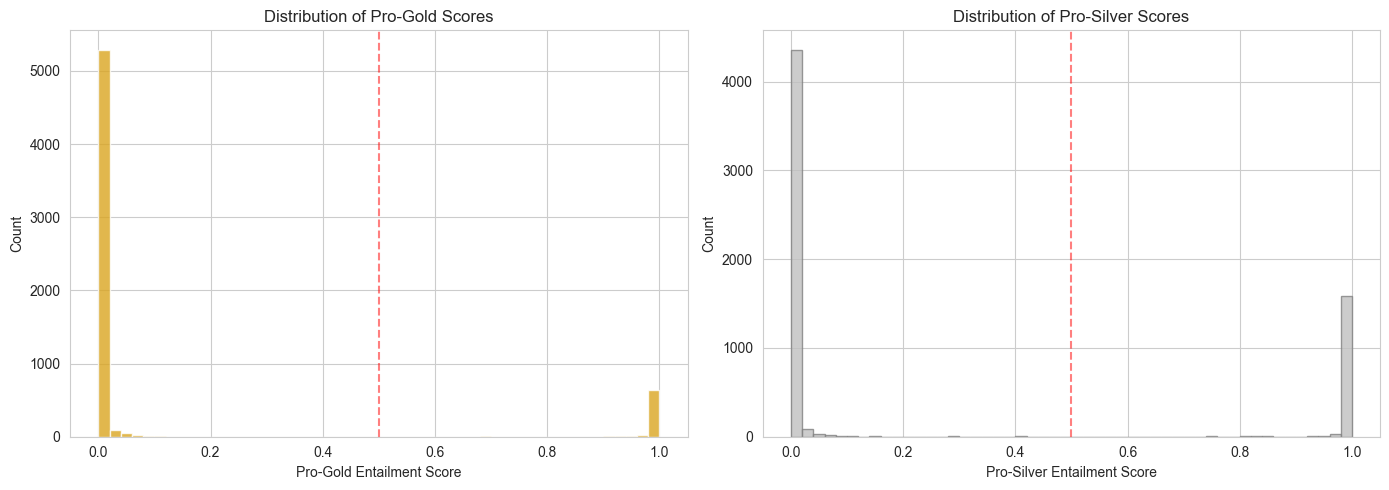

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_scored['pro_gold_score'].dropna(), bins=50, color='goldenrod', alpha=0.8)
axes[0].set_xlabel('Pro-Gold Entailment Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Pro-Gold Scores')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5)

axes[1].hist(df_scored['pro_silver_score'].dropna(), bins=50, color='silver', alpha=0.8,
             edgecolor='gray')
axes[1].set_xlabel('Pro-Silver Entailment Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Pro-Silver Scores')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

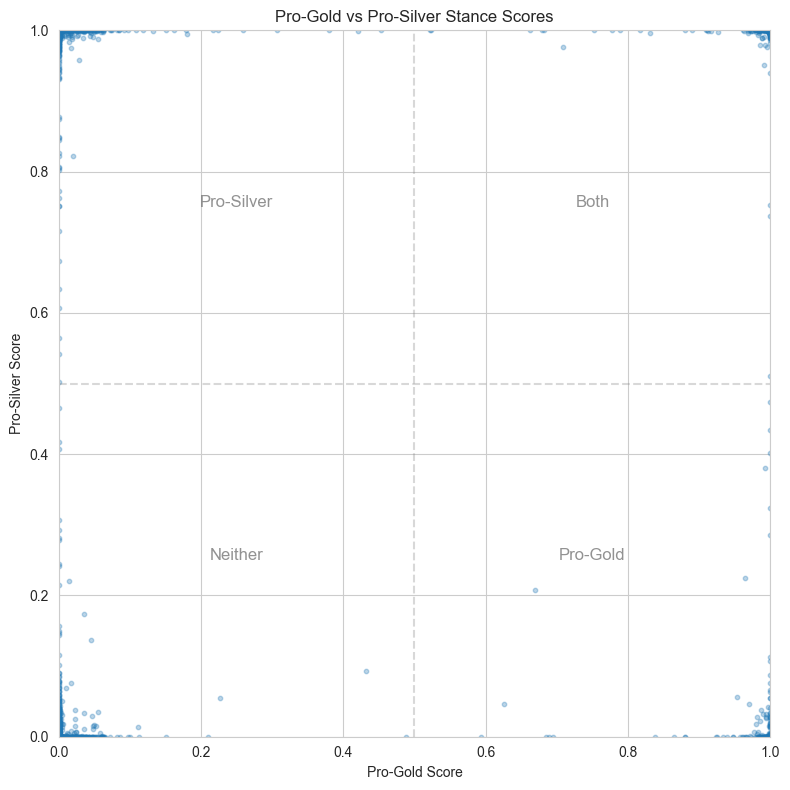

In [10]:
# Scatter: pro-gold vs pro-silver
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    df_scored['pro_gold_score'],
    df_scored['pro_silver_score'],
    alpha=0.3, s=10,
)
ax.set_xlabel('Pro-Gold Score')
ax.set_ylabel('Pro-Silver Score')
ax.set_title('Pro-Gold vs Pro-Silver Stance Scores')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Label quadrants
ax.text(0.75, 0.75, 'Both', ha='center', fontsize=12, alpha=0.5)
ax.text(0.25, 0.25, 'Neither', ha='center', fontsize=12, alpha=0.5)
ax.text(0.75, 0.25, 'Pro-Gold', ha='center', fontsize=12, alpha=0.5)
ax.text(0.25, 0.75, 'Pro-Silver', ha='center', fontsize=12, alpha=0.5)

plt.tight_layout()
plt.show()

## Validate: Check High-Confidence Classifications

Look at articles with the strongest pro-gold and pro-silver scores to sanity-check.

In [11]:
# Top 3 most pro-gold articles
print("=" * 80)
print("MOST PRO-GOLD ARTICLES")
print("=" * 80)
for _, row in df_scored.nlargest(3, 'pro_gold_score').iterrows():
    print(f"\nScore: {row['pro_gold_score']:.4f} | {row['newspaper_name']} | {row['date']}")
    print(f"Keywords: {row.get('matched_keywords', '')}")
    print(row['article'][:500])
    print("-" * 40)

MOST PRO-GOLD ARTICLES

Score: 1.0000 | The Russellville Democrat. | 1893-10-19
Keywords: coinage of gold|coinage of silver
WHAT we want is to liberate oul currency. As long as it is held in shackles of legal enactment there will be friction, and somebody will always be wanting to tinker with it. And that would unsettle confidence, as Wall street would say Free and unlimited coinage of silver. Free and unlimited coinage of gold. This will set the currency free. It will give it basis too broad to be affect ed by financial schemers. This pol icy, and this alone, will banish finan- cial panics, and cotton patch panics, 
----------------------------------------

Score: 1.0000 | The Daily Texarkanian. | 1895-09-13
Keywords: coinage of gold
1--WE believe that the rank and file
of the Democratic party should at
once assert themselves in the Dem
lcratic party on record in favor Of
,he I'M mediate restoration of the
rec and unlimited coinage of gold
and silver at the present legal ratio
OF l6 t

In [12]:
# Top 3 most pro-silver articles
print("=" * 80)
print("MOST PRO-SILVER ARTICLES")
print("=" * 80)
for _, row in df_scored.nlargest(3, 'pro_silver_score').iterrows():
    print(f"\nScore: {row['pro_silver_score']:.4f} | {row['newspaper_name']} | {row['date']}")
    print(f"Keywords: {row.get('matched_keywords', '')}")
    print(row['article'][:500])
    print("-" * 40)

MOST PRO-SILVER ARTICLES

Score: 1.0000 | Arizona silver belt. | 1890-11-01
Keywords: free coinage
Talk up the silver question. It is the great question of the hour, and now, as all ought to know, has the van tage ground. The first step has been taken, and We believe thereby g solid foot has been planted that will stand its ground and advance to a successful completion when free coinage becomes the law of the land For this we write and speak at all times and in all places. So let the agitation go on. Keep it moving every hour and every day. Talk it up on the street, on change and in all publi
----------------------------------------

Score: 1.0000 | The Wichita daily eagle. | 1891-11-20
Keywords: coinage of silver
would endanger the safety and stability
of the nations financial system. Dir.
Fosters speech was practically a reply
to this, though he did not say so. He
declared that there was no fonnda-
tion for their fears. He told them
that the business of the world was
getting too larg

## Hypothesis Sensitivity (Optional)

Try alternative hypothesis framings to see if results are robust.

In [13]:
# Alternative hypotheses to try
alt_hypotheses = {
    "v1 (default)": DEFAULT_HYPOTHESES,
    "v2 (longer)": {
        "pro_gold": "This text argues in favor of maintaining the gold standard for currency.",
        "pro_silver": "This text argues in favor of the free and unlimited coinage of silver.",
    },
    "v3 (simpler)": {
        "pro_gold": "This text favors gold.",
        "pro_silver": "This text favors silver.",
    },
}

# Test on a small sample
test_texts = df.sample(min(20, len(df)), random_state=123)['article'].str[:2000].tolist()

for name, hyps in alt_hypotheses.items():
    gold_scores = []
    silver_scores = []
    for text in test_texts:
        s = detector.detect_stances(text, hypotheses=hyps)
        gold_scores.append(s['pro_gold_score'])
        silver_scores.append(s['pro_silver_score'])
    print(f"\n{name}:")
    print(f"  Gold  mean={sum(gold_scores)/len(gold_scores):.3f}")
    print(f"  Silver mean={sum(silver_scores)/len(silver_scores):.3f}")


v1 (default):
  Gold  mean=0.150
  Silver mean=0.351

v2 (longer):
  Gold  mean=0.150
  Silver mean=0.303

v3 (simpler):
  Gold  mean=0.054
  Silver mean=0.295


## Save Results

In [14]:
SAVE_PATH = "../data/results/article_stances.parquet"

# Ensure matched_keywords is serializable
df_save = df_scored.copy()
if 'matched_keywords' in df_save.columns:
    df_save['matched_keywords'] = df_save['matched_keywords'].apply(
        lambda x: '|'.join(x) if isinstance(x, list) else x
    )

df_save.to_parquet(SAVE_PATH, index=False)
print(f"Saved {len(df_save):,} articles with stance scores to {SAVE_PATH}")

Saved 6,179 articles with stance scores to ../data/results/article_stances.parquet
